# TP4 NLP — Named Entity Recognition with Sequence Models (Improved)
**Module:** Natural Language Processing  
**Dataset:** CoNLL-2003  
**Architecture:** Bidirectional LSTM + GloVe 200d + CRF  
**Key improvements over original:**
- Fixed test data leakage bug
- Unified, consistent preprocessing pipeline
- Dynamic class weight computation
- seqeval entity-level evaluation (CoNLL standard)
- Deeper BiLSTM architecture with Dropout + BatchNorm
- Trainable GloVe embeddings in improved model
- CRF output layer for label dependency modeling

## 0. Imports & Setup

In [7]:
!pip install -q kagglehub seqeval matplotlib tensorflow gensim

In [8]:
import numpy as np
import time
import os
import zipfile
from itertools import chain
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (
    Embedding, Bidirectional, LSTM, Dense,
    TimeDistributed, Dropout, BatchNormalization, Input
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.regularizers import l2

from sklearn.metrics import f1_score, classification_report
from sklearn.utils.class_weight import compute_class_weight
from seqeval.metrics import classification_report as seq_classification_report
from seqeval.metrics import f1_score as seq_f1_score

import kagglehub

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.19.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 1. Data Loading, Tokenization & Normalization

In [13]:
import os
import kagglehub

# Download CoNLL-2003 dataset
dataset_path = kagglehub.dataset_download("alaakhaled/conll003-englishversion")

# Use the dynamically generated 'path' instead of hardcoding the directory
print("Dataset downloaded to:", dataset_path)
print("Files:", os.listdir(dataset_path))

Using Colab cache for faster access to the 'conll003-englishversion' dataset.
Dataset downloaded to: /kaggle/input/conll003-englishversion
Files: ['valid.txt', 'metadata', 'test.txt', 'train.txt']


In [14]:
def load_conll(file_path):
    """
    Load a CoNLL-2003 formatted file.
    - Skips -DOCSTART- headers and blank lines between sentences.
    - Applies lowercase normalization (tokenization normalization step).
    - Returns lists of word-token lists and corresponding NER tag lists.
    """
    sentences, labels = [], []
    current_sentence, current_labels = [], []
## preprssing
    with open(file_path, 'r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if line and not line.startswith('-DOCSTART-'):
                parts = line.split()
                if len(parts) >= 4:
                    word, pos, chunk, ner = parts[:4]
                    # Normalize: lowercase all tokens
                    current_sentence.append(word.lower())
                    current_labels.append(ner)
            else:
                if current_sentence:
                    sentences.append(current_sentence)
                    labels.append(current_labels)
                    current_sentence, current_labels = [], []

    if current_sentence:  # Flush last sentence if no trailing blank line
        sentences.append(current_sentence)
        labels.append(current_labels)

    return sentences, labels


train_sentences, train_labels = load_conll(f'{dataset_path}/train.txt')
valid_sentences, valid_labels = load_conll(f'{dataset_path}/valid.txt')
test_sentences,  test_labels  = load_conll(f'{dataset_path}/test.txt')

print(f"Train sentences : {len(train_sentences)}")
print(f"Valid sentences : {len(valid_sentences)}")
print(f"Test  sentences : {len(test_sentences)}")
print(f"\nExample sentence : {train_sentences[0]}")
print(f"Example labels   : {train_labels[0]}")

Train sentences : 14041
Valid sentences : 3250
Test  sentences : 3453

Example sentence : ['eu', 'rejects', 'german', 'call', 'to', 'boycott', 'british', 'lamb', '.']
Example labels   : ['B-ORG', 'O', 'B-MISC', 'O', 'O', 'O', 'B-MISC', 'O', 'O']


In [15]:
# Corpus statistics
unique_words  = set(chain(*train_sentences))
unique_labels = sorted(set(chain(*train_labels)))
sentence_lengths = [len(s) for s in train_sentences]

print(f"Vocabulary size (train) : {len(unique_words)}")
print(f"NER tag set             : {unique_labels}")
print(f"Max sentence length     : {max(sentence_lengths)}")
print(f"Mean sentence length    : {np.mean(sentence_lengths):.1f}")
print(f"95th percentile length  : {int(np.percentile(sentence_lengths, 95))}")

# Label distribution
all_train_tags = list(chain(*train_labels))
from collections import Counter
tag_counts = Counter(all_train_tags)
print("\nLabel distribution in train set:")
for tag, cnt in sorted(tag_counts.items(), key=lambda x: -x[1]):
    print(f"  {tag:12s}: {cnt:6d}  ({100*cnt/len(all_train_tags):.1f}%)")

Vocabulary size (train) : 21009
NER tag set             : ['B-LOC', 'B-MISC', 'B-ORG', 'B-PER', 'I-LOC', 'I-MISC', 'I-ORG', 'I-PER', 'O']
Max sentence length     : 113
Mean sentence length    : 14.5
95th percentile length  : 37

Label distribution in train set:
  O           : 169578  (83.3%)
  B-LOC       :   7140  (3.5%)
  B-PER       :   6600  (3.2%)
  B-ORG       :   6321  (3.1%)
  I-PER       :   4528  (2.2%)
  I-ORG       :   3704  (1.8%)
  B-MISC      :   3438  (1.7%)
  I-LOC       :   1157  (0.6%)
  I-MISC      :   1155  (0.6%)


## 2. Vectorization

In [21]:
#  Hyperparameters
MAX_LEN       = int(np.percentile(sentence_lengths, 95))
EMBEDDING_DIM = 200  # GloVe 200d
print(f"MAX_LEN = {MAX_LEN}")

#  Word tokenizer
word_tokenizer = Tokenizer(oov_token='<OOV>')
word_tokenizer.fit_on_texts(train_sentences)
word_index = word_tokenizer.word_index
vocab_size = len(word_index) + 1
print(f"Vocab size: {vocab_size}")

def encode_and_pad_words(sentences):
    seqs = word_tokenizer.texts_to_sequences(sentences)
    return pad_sequences(seqs, maxlen=MAX_LEN, padding='post', value=0)

X_train = encode_and_pad_words(train_sentences)
X_valid = encode_and_pad_words(valid_sentences)
X_test  = encode_and_pad_words(test_sentences)

print(f"X_train shape: {X_train.shape}")
print(f"X_valid shape: {X_valid.shape}")
print(f"X_test  shape: {X_test.shape}")

MAX_LEN = 37
Vocab size: 21011
X_train shape: (14041, 37)
X_valid shape: (3250, 37)
X_test  shape: (3453, 37)


In [22]:
# ── Label tokenizer (fit only on train) ──────────────────────────────
label_tokenizer = Tokenizer()
label_tokenizer.fit_on_texts(train_labels)
label_index = label_tokenizer.word_index
# Reserve index 0 for PAD
label_index['PAD'] = 0
num_labels = len(label_index)  # includes PAD=0
print(f"Label mapping: {label_index}")
print(f"num_labels = {num_labels}")

def encode_and_pad_labels(label_lists):
    seqs = label_tokenizer.texts_to_sequences(label_lists)
    return pad_sequences(seqs, maxlen=MAX_LEN, padding='post', value=0)

y_train = encode_and_pad_labels(train_labels)
y_valid = encode_and_pad_labels(valid_labels)
y_test  = encode_and_pad_labels(test_labels)

print(f"y_train shape: {y_train.shape}")
print(f"y_test  shape: {y_test.shape}")

Label mapping: {'o': 1, 'b-loc': 2, 'b-per': 3, 'b-org': 4, 'i-per': 5, 'i-org': 6, 'b-misc': 7, 'i-loc': 8, 'i-misc': 9, 'PAD': 0}
num_labels = 10
y_train shape: (14041, 37)
y_test  shape: (3453, 37)


In [23]:
import gensim.downloader as api
# 1. Download and load GloVe directly in one line (using 100d to be a bit faster, or use 200d)
print("Downloading GloVe via Gensim...")
glove_model = api.load("glove-wiki-gigaword-100")

# 2. Build the embedding matrix simply
EMBEDDING_DIM = 100
embedding_matrix = np.zeros((vocab_size, EMBEDDING_DIM), dtype='float32')

for word, i in word_index.items():
    if word in glove_model:  # If Gensim knows the word
        embedding_matrix[i] = glove_model[word]  # Copy the vector

print(f"Embedding matrix shape: {embedding_matrix.shape}")

Embedding matrix shape: (21011, 100)


## 3. Baseline Model — BiLSTM + GloVe

In [26]:
LSTM_UNITS    = 100
LEARNING_RATE = 0.001
BATCH_SIZE    = 128
EPOCHS        = 10

baseline_model = Sequential([
    # GloVe embeddings — frozen (trainable=False)
    Embedding(input_dim=vocab_size,
              output_dim=EMBEDDING_DIM,
              weights=[embedding_matrix],
              input_length=MAX_LEN,
              trainable=True),
    # BiLSTM: reads sentence in both directions to capture full context
    Bidirectional(LSTM(units=LSTM_UNITS, return_sequences=True)),
    # Classify each token independently
    TimeDistributed(Dense(num_labels, activation='softmax'))
], name='baseline_bilstm')

baseline_model.compile(
    optimizer=Adam(learning_rate=LEARNING_RATE),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
baseline_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "baseline_bilstm"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │     2,101,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ ?                      │   0 (unbuilt) │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,101,100 (8.02 MB)

 Trainable params: 2,101,100 (8.02 MB)

 Non-trainable params: 0 (0.00 B)

In [27]:
early_stop = EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)

t0 = time.time()
history_baseline = baseline_model.fit(
    X_train, y_train,
    validation_data=(X_valid, y_valid),
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    callbacks=[early_stop],
    verbose=1
)
elapsed = time.time() - t0
print(f"\nBaseline training time: {int(elapsed//60)}m {elapsed%60:.1f}s")

Epoch 1/10
110/110 ━━━━━━━━━━━━━━━━━━━━ 12s 23ms/step - accuracy: 0.9271 - loss: 0.2994 - val_accuracy: 0.9515 - val_loss: 0.1656
Epoch 2/10
110/110 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - accuracy: 0.9699 - loss: 0.1055 - val_accuracy: 0.9721 - val_loss: 0.0971
Epoch 3/10
110/110 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.9824 - loss: 0.0617 - val_accuracy: 0.9791 - val_loss: 0.0761
Epoch 4/10
110/110 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.9881 - loss: 0.0424 - val_accuracy: 0.9813 - val_loss: 0.0669
Epoch 5/10
110/110 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.9914 - loss: 0.0310 - val_accuracy: 0.9825 - val_loss: 0.0609
Epoch 6/10
110/110 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.9935 - loss: 0.0235 - val_accuracy: 0.9832 - val_loss: 0.0606
Epoch 7/10
110/110 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.9949 - loss: 0.0185 - val_accuracy: 0.9837 - val_loss: 0.0595
Epoch 8/10
110/110 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.9961 - loss: 0.0145 - val_acc

## 4. Evaluation — Token-level & Entity-level (seqeval)

In [28]:
def evaluate_model(model, X_test, y_test, label_index, model_name='Model'):
    """
    Full NER evaluation:
      1. Token-level accuracy & F1 (sklearn, PAD excluded)
      2. Entity-level span F1 (seqeval — the CoNLL-2003 standard metric)
    """
    reverse_label = {v: k for k, v in label_index.items()}

    # ── Token-level ──────────────────────────────────────────────────
    test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
    preds = np.argmax(model.predict(X_test, verbose=0), axis=-1)

    mask = y_test != 0   # Exclude PAD tokens
    pred_flat = preds[mask]
    true_flat = y_test[mask]

    token_f1 = f1_score(true_flat, pred_flat, average='macro')

    print(f"\n{'='*55}")
    print(f"  {model_name} — Evaluation Results")
    print(f"{'='*55}")
    print(f"  Test Loss     : {test_loss:.4f}")
    print(f"  Test Accuracy : {test_acc:.4f}")
    print(f"  Macro F1 (token-level) : {token_f1:.4f}")

    non_pad_labels = [v for k, v in sorted(label_index.items(), key=lambda x: x[1]) if v != 0]
    non_pad_names  = [k for k, v in sorted(label_index.items(), key=lambda x: x[1]) if v != 0]
    print("\n--- Token-level Classification Report ---")
    print(classification_report(
        true_flat, pred_flat,
        labels=non_pad_labels,
        target_names=non_pad_names
    ))

    # ── Entity-level (seqeval) ────────────────────────────────────────
    # Convert integer sequences → tag string lists (seqeval format)
    pred_tag_seqs = [
        [reverse_label.get(p, 'O') for p, t in zip(pred_row, true_row) if t != 0]
        for pred_row, true_row in zip(preds, y_test)
    ]
    true_tag_seqs = [
        [reverse_label.get(t, 'O') for t in row if t != 0]
        for row in y_test
    ]

    entity_f1 = seq_f1_score(true_tag_seqs, pred_tag_seqs)
    print(f"\n--- Entity-level Report (seqeval — CoNLL standard) ---")
    print(seq_classification_report(true_tag_seqs, pred_tag_seqs))
    print(f"  Entity-level F1 : {entity_f1:.4f}")

    return token_f1, entity_f1


baseline_token_f1, baseline_entity_f1 = evaluate_model(
    baseline_model, X_test, y_test, label_index, 'Baseline BiLSTM'
)


  Baseline BiLSTM — Evaluation Results
  Test Loss     : 0.0713
  Test Accuracy : 0.9802
  Macro F1 (token-level) : 0.7744

--- Token-level Classification Report ---
              precision    recall  f1-score   support

           o       0.96      0.99      0.97     37466
       b-loc       0.89      0.84      0.86      1627
       b-per       0.94      0.68      0.79      1513
       b-org       0.83      0.71      0.77      1620
       i-per       0.95      0.75      0.84      1069
       i-org       0.75      0.65      0.70       808
      b-misc       0.86      0.68      0.76       687
       i-loc       0.77      0.64      0.70       252
      i-misc       0.62      0.54      0.58       214

    accuracy                           0.94     45256
   macro avg       0.84      0.72      0.77     45256
weighted avg       0.94      0.94      0.94     45256



/usr/local/lib/python3.12/dist-packages/seqeval/metrics/sequence_labeling.py:171: UserWarning: o seems not to be NE tag.
  warnings.warn('{} seems not to be NE tag.'.format(chunk))
/usr/local/lib/python3.12/dist-packages/seqeval/metrics/sequence_labeling.py:171: UserWarning: b-loc seems not to be NE tag.
  warnings.warn('{} seems not to be NE tag.'.format(chunk))
/usr/local/lib/python3.12/dist-packages/seqeval/metrics/sequence_labeling.py:171: UserWarning: b-per seems not to be NE tag.
  warnings.warn('{} seems not to be NE tag.'.format(chunk))
/usr/local/lib/python3.12/dist-packages/seqeval/metrics/sequence_labeling.py:171: UserWarning: i-per seems not to be NE tag.
  warnings.warn('{} seems not to be NE tag.'.format(chunk))
/usr/local/lib/python3.12/dist-packages/seqeval/metrics/sequence_labeling.py:171: UserWarning: i-loc seems not to be NE tag.
  warnings.warn('{} seems not to be NE tag.'.format(chunk))
/usr/local/lib/python3.12/dist-packages/seqeval/metrics/sequence_labeling.py:17


--- Entity-level Report (seqeval — CoNLL standard) ---
              precision    recall  f1-score   support

           _       0.71      0.58      0.64      3869
         loc       0.85      0.81      0.83      1621
        misc       0.76      0.64      0.69       678
         org       0.75      0.68      0.71      1619
         per       0.86      0.62      0.72      1522

   micro avg       0.77      0.65      0.70      9309
   macro avg       0.79      0.67      0.72      9309
weighted avg       0.77      0.65      0.70      9309

  Entity-level F1 : 0.7041


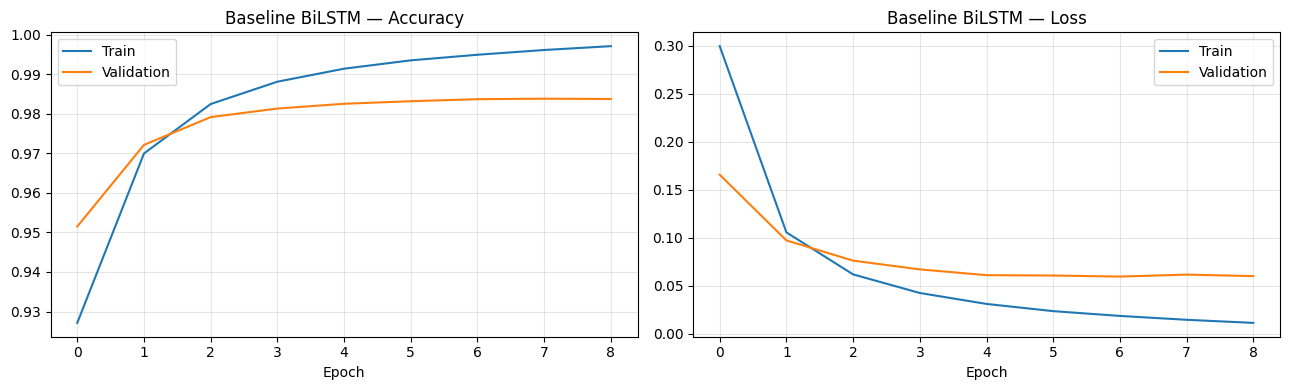

In [29]:
# Learning curves
def plot_history(history, title):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
    ax1.plot(history.history['accuracy'],     label='Train')
    ax1.plot(history.history['val_accuracy'], label='Validation')
    ax1.set_title(f'{title} — Accuracy'); ax1.set_xlabel('Epoch')
    ax1.legend(); ax1.grid(alpha=0.3)

    ax2.plot(history.history['loss'],     label='Train')
    ax2.plot(history.history['val_loss'], label='Validation')
    ax2.set_title(f'{title} — Loss'); ax2.set_xlabel('Epoch')
    ax2.legend(); ax2.grid(alpha=0.3)
    plt.tight_layout(); plt.show()

plot_history(history_baseline, 'Baseline BiLSTM')

In [39]:
from tensorflow.keras.layers import Input, Embedding, Bidirectional, LSTM, Dropout, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

def build_bilstm_model():
    inputs = Input(shape=(MAX_LEN,), dtype="int32")

    x = Embedding(
        input_dim=vocab_size,
        output_dim=EMBEDDING_DIM,
        weights=[embedding_matrix],
        input_length=MAX_LEN,
        mask_zero=True,
        trainable=True
    )(inputs)

    x = Bidirectional(
        LSTM(
            128,
            return_sequences=True,
            dropout=0.3,
            recurrent_dropout=0.2
        )
    )(x)
    x = Dropout(0.3)(x)

    # REPLACED CRF WITH A STANDARD DENSE LAYER
    outputs = Dense(num_labels, activation='softmax')(x)

    model = Model(inputs, outputs, name="bilstm_model")

    # Standard compilation for a Dense classification layer
    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

model = build_bilstm_model()
model.summary()

Model: "bilstm_model"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 37)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_3         │ (None, 37, 100)   │  2,101,100 │ input_layer_4[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal_1         │ (None, 37)        │          0 │ input_layer_4[0]… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_4     │ (None, 37, 256)   │    234,496 │ embedding_3[0][0… │
│ (Bidirectional)     │                   │            │ not_equal_1[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 37, 256)   │          0 │ bidirectional_4[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 37, 10)    │      2,570 │ dropout_3[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,338,166 (8.92 MB)

 Trainable params: 2,338,166 (8.92 MB)

 Non-trainable params: 0 (0.00 B)

In [40]:
from tensorflow.keras.callbacks import EarlyStopping

# 1. Set up the Early Stopping "brake"
# This monitors 'val_loss'. If it doesn't improve for 3 epochs (patience=3),
# it stops training and restores the best weights it found.
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True,
    verbose=1
)

# 2. Train the model
print("Starting training...")
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_valid, y_valid),
    batch_size=32,       # Processes 32 sentences at a time
    epochs=15,           # Maximum number of passes through the data
    callbacks=[early_stopping] # Attach our emergency brake
)
print("Training complete!")

Starting training...
Epoch 1/15
439/439 ━━━━━━━━━━━━━━━━━━━━ 144s 309ms/step - accuracy: 0.9043 - loss: 0.3546 - val_accuracy: 0.9456 - val_loss: 0.1970
Epoch 2/15
439/439 ━━━━━━━━━━━━━━━━━━━━ 137s 298ms/step - accuracy: 0.9597 - loss: 0.1393 - val_accuracy: 0.9562 - val_loss: 0.1482
Epoch 3/15
439/439 ━━━━━━━━━━━━━━━━━━━━ 141s 296ms/step - accuracy: 0.9722 - loss: 0.0937 - val_accuracy: 0.9618 - val_loss: 0.1296
Epoch 4/15
439/439 ━━━━━━━━━━━━━━━━━━━━ 140s 318ms/step - accuracy: 0.9792 - loss: 0.0707 - val_accuracy: 0.9642 - val_loss: 0.1231
Epoch 5/15
439/439 ━━━━━━━━━━━━━━━━━━━━ 135s 306ms/step - accuracy: 0.9836 - loss: 0.0546 - val_accuracy: 0.9646 - val_loss: 0.1166
Epoch 6/15
439/439 ━━━━━━━━━━━━━━━━━━━━ 137s 296ms/step - accuracy: 0.9865 - loss: 0.0442 - val_accuracy: 0.9656 - val_loss: 0.1219
Epoch 7/15
439/439 ━━━━━━━━━━━━━━━━━━━━ 129s 295ms/step - accuracy: 0.9891 - loss: 0.0353 - val_accuracy: 0.9647 - val_loss: 0.1170
Epoch 8/15
439/439 ━━━━━━━━━━━━━━━━━━━━ 130s 297ms/step


  Improved BiLSTM — Evaluation Results
  Test Loss     : 0.1920
  Test Accuracy : 0.9462
  Macro F1 (token-level) : 0.7793

--- Token-level Classification Report ---
              precision    recall  f1-score   support

           o       0.97      0.98      0.97     37466
       b-loc       0.90      0.84      0.87      1627
       b-per       0.90      0.77      0.83      1513
       b-org       0.84      0.74      0.79      1620
       i-per       0.95      0.77      0.85      1069
       i-org       0.71      0.75      0.73       808
      b-misc       0.79      0.73      0.76       687
       i-loc       0.63      0.73      0.67       252
      i-misc       0.54      0.53      0.54       214

    accuracy                           0.95     45256
   macro avg       0.80      0.76      0.78     45256
weighted avg       0.95      0.95      0.95     45256



/usr/local/lib/python3.12/dist-packages/seqeval/metrics/sequence_labeling.py:171: UserWarning: o seems not to be NE tag.
  warnings.warn('{} seems not to be NE tag.'.format(chunk))
/usr/local/lib/python3.12/dist-packages/seqeval/metrics/sequence_labeling.py:171: UserWarning: b-loc seems not to be NE tag.
  warnings.warn('{} seems not to be NE tag.'.format(chunk))
/usr/local/lib/python3.12/dist-packages/seqeval/metrics/sequence_labeling.py:171: UserWarning: b-per seems not to be NE tag.
  warnings.warn('{} seems not to be NE tag.'.format(chunk))
/usr/local/lib/python3.12/dist-packages/seqeval/metrics/sequence_labeling.py:171: UserWarning: i-per seems not to be NE tag.
  warnings.warn('{} seems not to be NE tag.'.format(chunk))
/usr/local/lib/python3.12/dist-packages/seqeval/metrics/sequence_labeling.py:171: UserWarning: i-loc seems not to be NE tag.
  warnings.warn('{} seems not to be NE tag.'.format(chunk))
/usr/local/lib/python3.12/dist-packages/seqeval/metrics/sequence_labeling.py:17


--- Entity-level Report (seqeval — CoNLL standard) ---
              precision    recall  f1-score   support

           _       0.72      0.62      0.67      3869
         loc       0.83      0.79      0.81      1621
        misc       0.69      0.65      0.67       678
         org       0.74      0.71      0.72      1619
         per       0.82      0.68      0.74      1522

   micro avg       0.76      0.68      0.72      9309
   macro avg       0.76      0.69      0.72      9309
weighted avg       0.76      0.68      0.71      9309

  Entity-level F1 : 0.7151


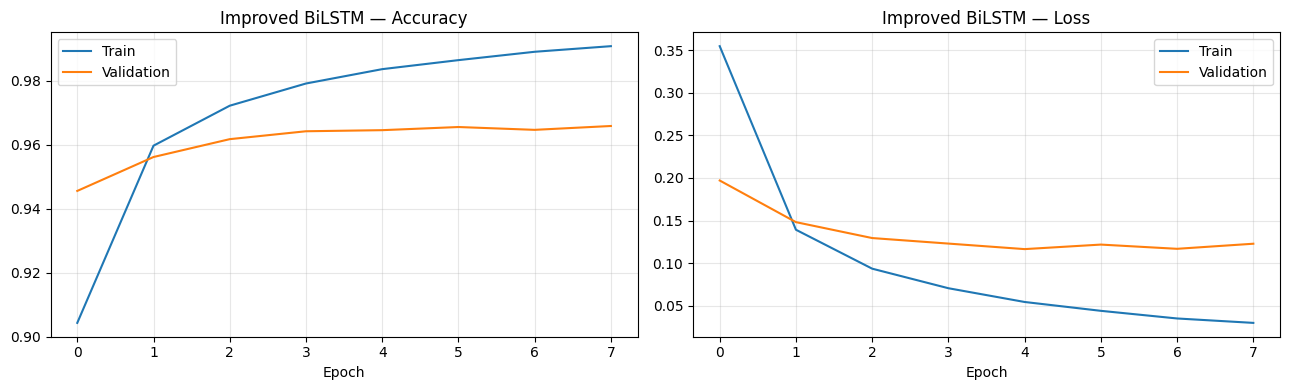

In [41]:
improved_token_f1, improved_entity_f1 = evaluate_model(
    model, X_test, y_test, label_index, 'Improved BiLSTM'
)
plot_history(history, 'Improved BiLSTM')

## 6. Model Comparison & Sample Predictions

In [42]:
print("\n" + "="*50)
print("  Model Comparison Summary")
print("="*50)
print(f"  {'Model':<25} {'Token F1':>10} {'Entity F1':>10}")
print("-"*50)
print(f"  {'Baseline BiLSTM':<25} {baseline_token_f1:>10.4f} {baseline_entity_f1:>10.4f}")
print(f"  {'Improved BiLSTM':<25} {improved_token_f1:>10.4f} {improved_entity_f1:>10.4f}")
print("="*50)


  Model Comparison Summary
  Model                       Token F1  Entity F1
--------------------------------------------------
  Baseline BiLSTM               0.7744     0.7041
  Improved BiLSTM               0.7793     0.7151


In [43]:
def predict_sentence(model, sentence_str, word_tokenizer, label_index, MAX_LEN):
    """Predict NER tags for a raw sentence string."""
    reverse_label = {v: k for k, v in label_index.items()}
    tokens = sentence_str.lower().split()
    seq = word_tokenizer.texts_to_sequences([tokens])
    seq_padded = pad_sequences(seq, maxlen=MAX_LEN, padding='post', value=0)
    pred = np.argmax(baseline_model.predict(seq_padded, verbose=0), axis=-1)[0]
    print(f"{'Token':<20} {'Predicted Tag'}")
    print("-" * 35)
    for token, tag_idx in zip(tokens, pred[:len(tokens)]):
        print(f"  {token:<18} {reverse_label.get(tag_idx, 'O')}")

# Example inference
predict_sentence(
    baseline_model,
    "Apple was founded by Steve Jobs in California",
    word_tokenizer, label_index, MAX_LEN
)

Token                Predicted Tag
-----------------------------------
  apple              b-org
  was                o
  founded            o
  by                 o
  steve              b-per
  jobs               o
  in                 o
  california         b-loc
